In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
sys.path.append('../src')

In [3]:
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

In [4]:
from spaceoracle.models.estimators import GCNNWR 
from spaceoracle.tools.data import load_example_slideseq, filter_adata
from spaceoracle.tools.network import GeneRegulatoryNetwork

which: no R in (/ix/djishnu/alw399/envs/bee/bin:/ix/djishnu/alw399/envs/bee/bin:/ihome/crc/install/python/ondemand-jupyter-python3.10-2023.03/condabin:/ihome/crc/install/ondemand/code-server/code-server-4.5.1-linux-amd64/lib/vscode/bin/remote-cli:/ihome/crc/install/python/ondemand-jupyter-python3.10-2023.03/bin:/ihome/crc/install/ondemand/code-server/code-server-4.5.1-linux-amd64/bin:/ihome/crc/install/git/2.33.0/bin:/ihome/hosmanbeyoglu/alw399/.local/bin:/ihome/hosmanbeyoglu/alw399/bin:/usr/local/bin:/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/ihome/crc/pipx/bin:/ihome/crc/install/gcc-8.2.0/bedtools/bedtools2-2.30.0/bin:/ihome/hosmanbeyoglu/alw399/.local/bin:/ihome/hosmanbeyoglu/alw399/bin:/usr/local/bin:/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/ihome/crc/pipx/bin:/ihome/crc/pipx/bin:/ihome/crc/install/gcc-8.2.0/bedtools/bedtools2-2.30.0/bin:/ihome/hosmanbeyoglu/alw399/.local/bin:/ihome/hosmanbeyoglu/alw399/bin:/usr/local/bin:/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/ihome/crc/pipx/bin:/ih

In [5]:
slideseq_data = load_example_slideseq('../data/slideseq/')
slideseq_data

[AnnData object with n_obs × n_vars = 39721 × 24649
     obs: 'cluster'
     uns: 'cluster_colors'
     obsm: 'X_spatial', 'spatial',
 AnnData object with n_obs × n_vars = 30242 × 25343
     obs: 'cluster'
     obsm: 'X_spatial', 'spatial',
 AnnData object with n_obs × n_vars = 50058 × 19041
     obs: 'cluster'
     obsm: 'X_spatial', 'spatial',
 AnnData object with n_obs × n_vars = 41361 × 18972
     obs: 'cluster'
     obsm: 'X_spatial', 'spatial']

In [6]:
adata = slideseq_data[0].copy()

In [7]:
adata = filter_adata(adata, min_counts=500)
adata

View of AnnData object with n_obs × n_vars = 9984 × 2000
    obs: 'cluster', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'log1p', 'hvg'
    obsm: 'X_spatial', 'spatial'
    layers: 'raw_count'

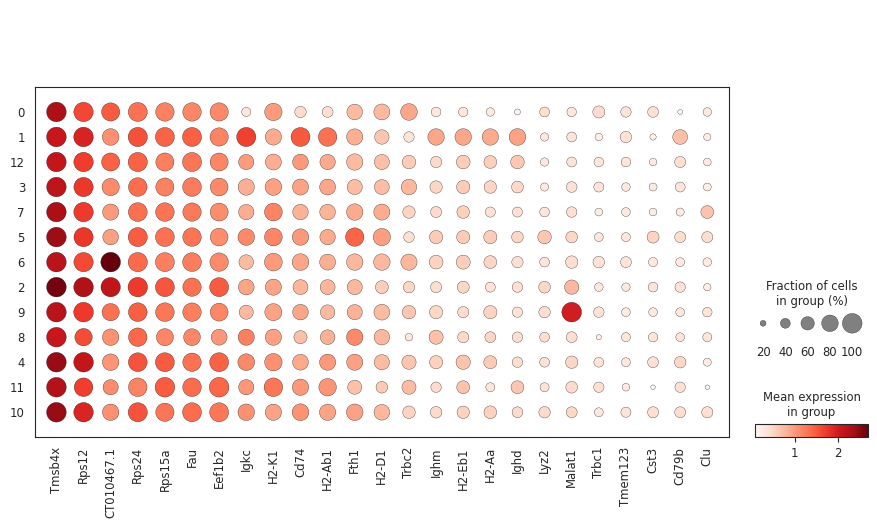

In [8]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (1, 1)
plt.rcParams['figure.dpi'] = 100
sc.pl.dotplot(adata, var_names=adata.var.means.sort_values(ascending=False)[:25].index, groupby='cluster')

In [9]:
adata.var.means.sort_values(ascending=False)[:15]

Tmsb4x        2.314449
Rps12         1.864198
CT010467.1    1.704301
Rps24         1.542029
Rps15a        1.416875
Fau           1.389121
Eef1b2        1.290448
Igkc          1.219202
H2-K1         1.121229
Cd74          1.079870
H2-Ab1        0.988318
Fth1          0.970740
H2-D1         0.875278
Trbc2         0.866577
Ighm          0.756234
Name: means, dtype: float64

In [10]:
target_gene = 'Cd74'

In [11]:
grn = GeneRegulatoryNetwork()

In [12]:
regulators = grn.get_regulators(adata, target_gene=target_gene)
regulators, len(regulators)

(['Atf3',
  'Bcl11a',
  'Ebf1',
  'Ebf3',
  'Egr2',
  'Gata1',
  'Gata2',
  'Mef2a',
  'Mef2c',
  'Pax5',
  'Pou2f2',
  'Prdm9',
  'Snai3',
  'Stat2',
  'Taf1',
  'Tal1'],
 16)

In [13]:
from spaceoracle.models.estimators import GeoCNNEstimator

In [14]:
estimator = GeoCNNEstimator()

In [15]:
X = adata.to_df()[regulators]
X

,Atf3,Bcl11a,Ebf1,Ebf3,Egr2,Gata1,Gata2,Mef2a,Mef2c,Pax5,Pou2f2,Prdm9,Snai3,Stat2,Taf1,Tal1
AAAAATCGCGTCCA,0.0,0.0,0.643342,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0
AAAACCTCACATTT,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.458739,0.0,0.0,0.000000,0.000000,0.0
AAAACGTGATCCTA,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.691110,0.000000,0.0
AAAACTATTTAAGG,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0
AAAAGATGCTCAGC,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,1.512969,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTTTTCGACAGAG,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.646273,0.0
TTTTTTCGCGGCTA,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0
TTTTTTGGGCTGGT,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.423997,0.0,0.0,0.423997,0.000000,0.0
TTTTTTGTACGATT,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.857282,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0


In [16]:
y = adata.to_df()[[target_gene]]
y

,Cd74
AAAAATCGCGTCCA,0.000000
AAAACCTCACATTT,0.772030
AAAACGTGATCCTA,1.095895
AAAACTATTTAAGG,0.000000
AAAAGATGCTCAGC,1.744014
...,...
TTTTTTCGACAGAG,0.000000
TTTTTTCGCGGCTA,0.000000
TTTTTTGGGCTGGT,0.000000
TTTTTTGTACGATT,1.860506


In [17]:
xy = adata.obsm['spatial']

barcodes = adata.obs.index
c = adata.obs.loc[barcodes, 'cluster'].values.reshape(-1, 1)
xyc = np.concatenate([xy, c], axis=1)

nclusters = len(np.unique(xyc[:,2]))

print(xyc.shape)

(9984, 3)


In [19]:
estimator.fit(X.values[:9000, :], y.values[:9000], xyc[:9000, :], in_channels = nclusters, init_betas='ols', max_epochs=200, learning_rate=3e-3, spatial_dim=128)

MSE: 0.2731 | OLS: 0.5924: 100%|██████████| 200/200 [24:07<00:00,  7.24s/it]


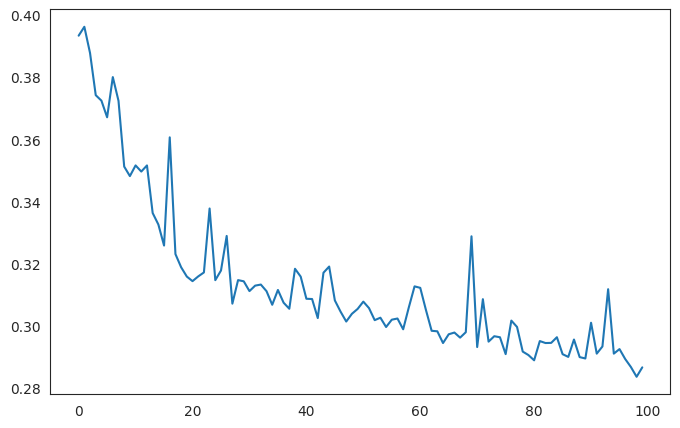

In [ ]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.plot(estimator.losses)
plt.show()

In [22]:
betas, y_pred = estimator.get_betas(X.values[9000:, :], xyc[9000:, :])

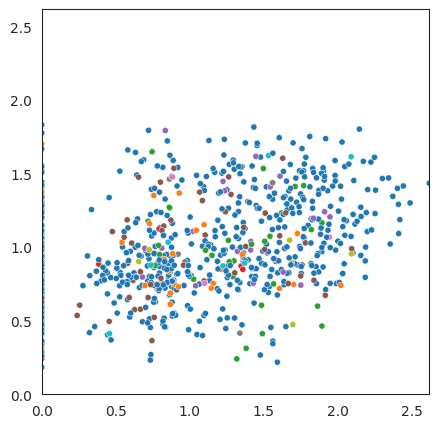

In [23]:
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.dpi'] = 100
sns.scatterplot(x=y.values[9000:, :].reshape(-1), y=y_pred.reshape(-1), s=20, c=adata.obs.cluster.values[9000:], cmap='tab10')
plt.xlim(y.values[9000:, :].min(), y.values[9000:, :].max())
plt.ylim(y.values[9000:, :].min(), y.values[9000:, :].max())
plt.show()

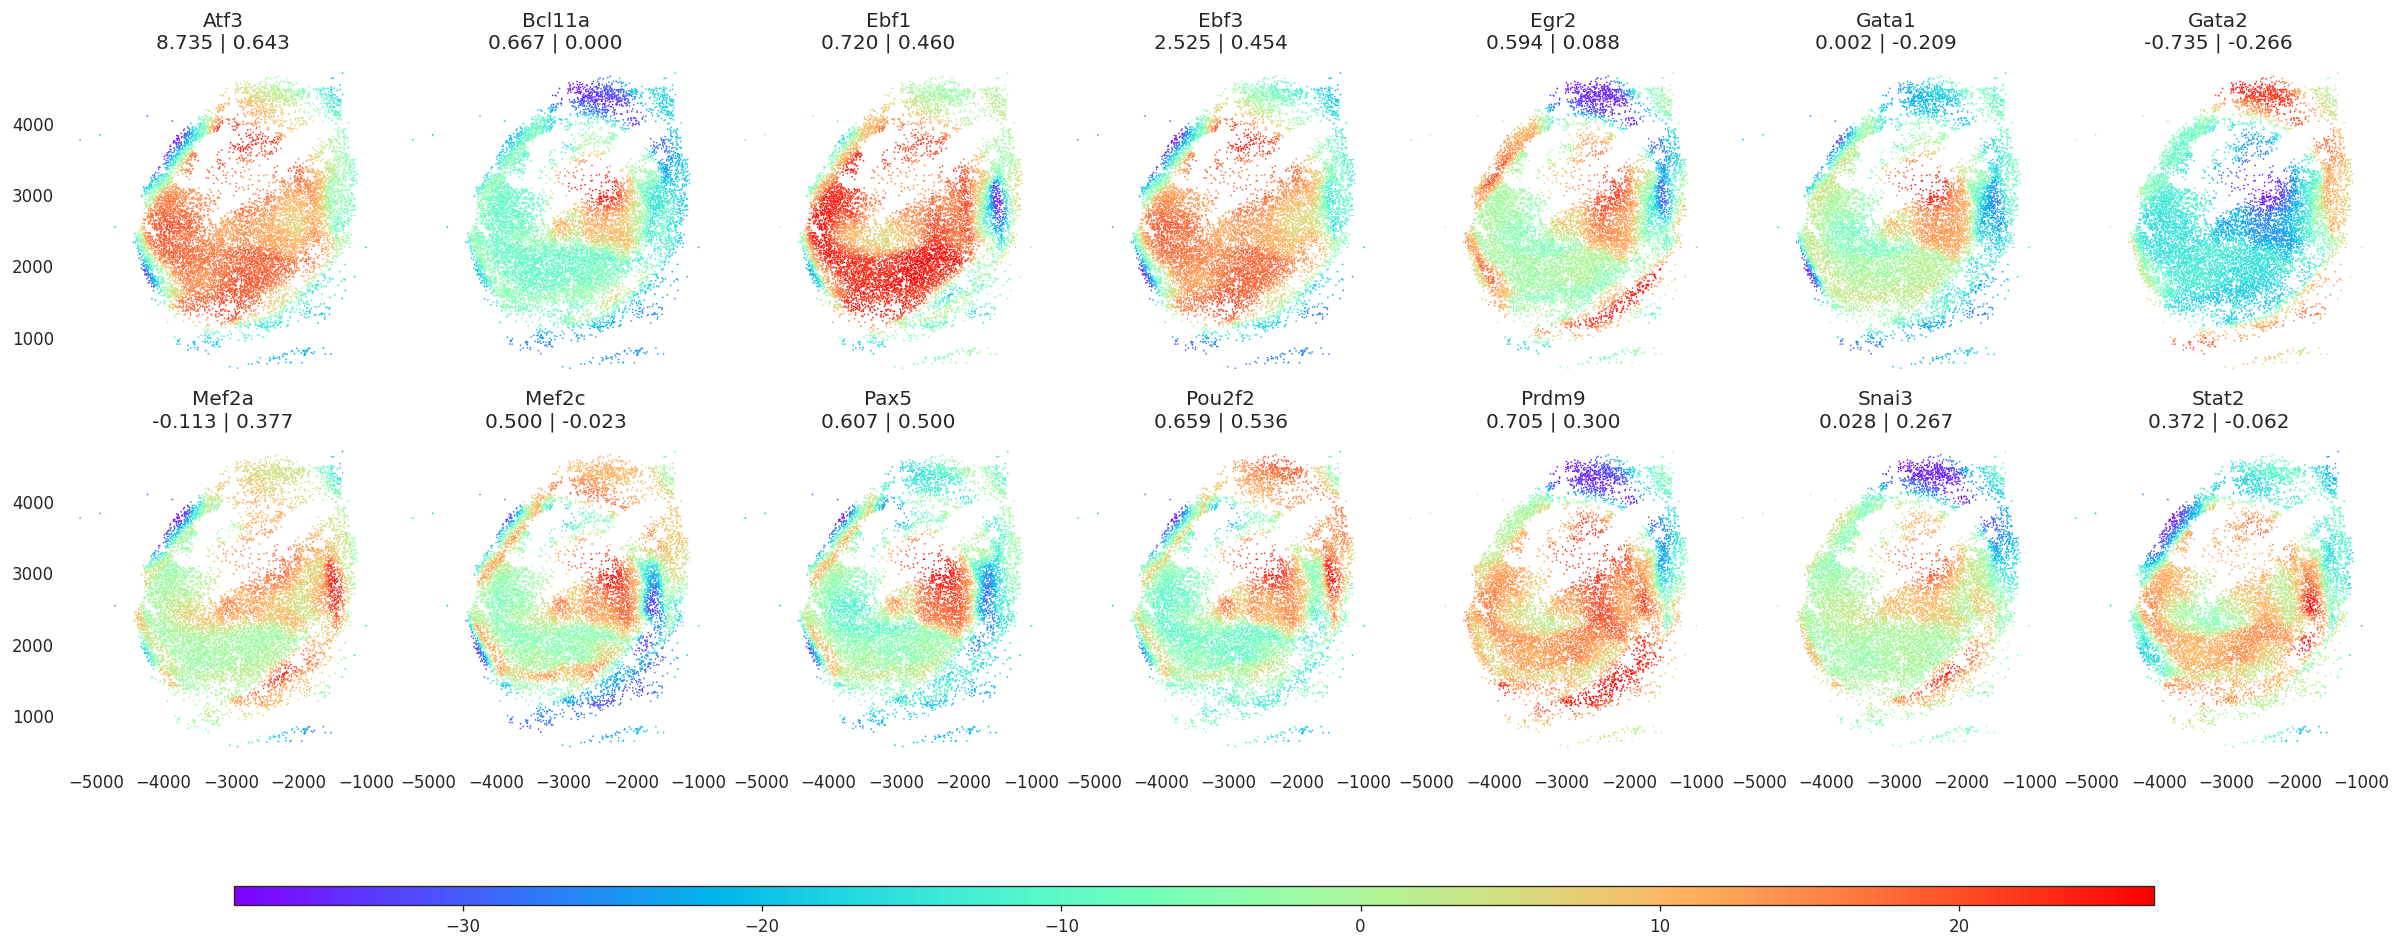

In [ ]:
f, axs = plt.subplots(2, 7, figsize=(20, 8), dpi=120, sharex=True, sharey=True)
axs = axs.flatten()

scatter_plots = []

for i in range(len(axs)): 
    scatter = sns.scatterplot(x=adata.obsm['spatial'][9000:, 0], y=adata.obsm['spatial'][9000:, 1], 
                s=15, c=betas[:, i+1], cmap='rainbow', ax=axs[i], edgecolor=None, linewidth=0)
    scatter_plots.append(scatter)

beta_means = list(betas.mean(0))
for ix, ax in enumerate(axs):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_title(f'{regulators[ix]}\n{beta_means[ix+1]:.3f} | {estimator.beta_init[ix]:.3f}')

# Adjust the layout to make space for the colorbar
plt.tight_layout()
f.subplots_adjust(bottom=0.2)

# Add a colorbar
cbar_ax = f.add_axes([0.1, 0.05, 0.8, 0.02])
colorbar = f.colorbar(scatter_plots[0].collections[0], cax=cbar_ax, orientation='horizontal')

plt.show()